# 🛒 Retail Sales Analytics with Python

## Exploratory Data Analysis (EDA)

### Project Overview

This project presents an end-to-end exploratory data analysis of the Superstore Sales Analytics dataset using Python.

The objective is to transform raw retail sales data into meaningful business insights through data cleaning, feature engineering, visualization, and statistical analysis.

The notebook follows a structured analytical workflow commonly used in real-world data analytics projects.

---

## Tools & Technologies

- Python
- Pandas
- NumPy
- Plotly
- Matplotlib
- Kaggle Notebook
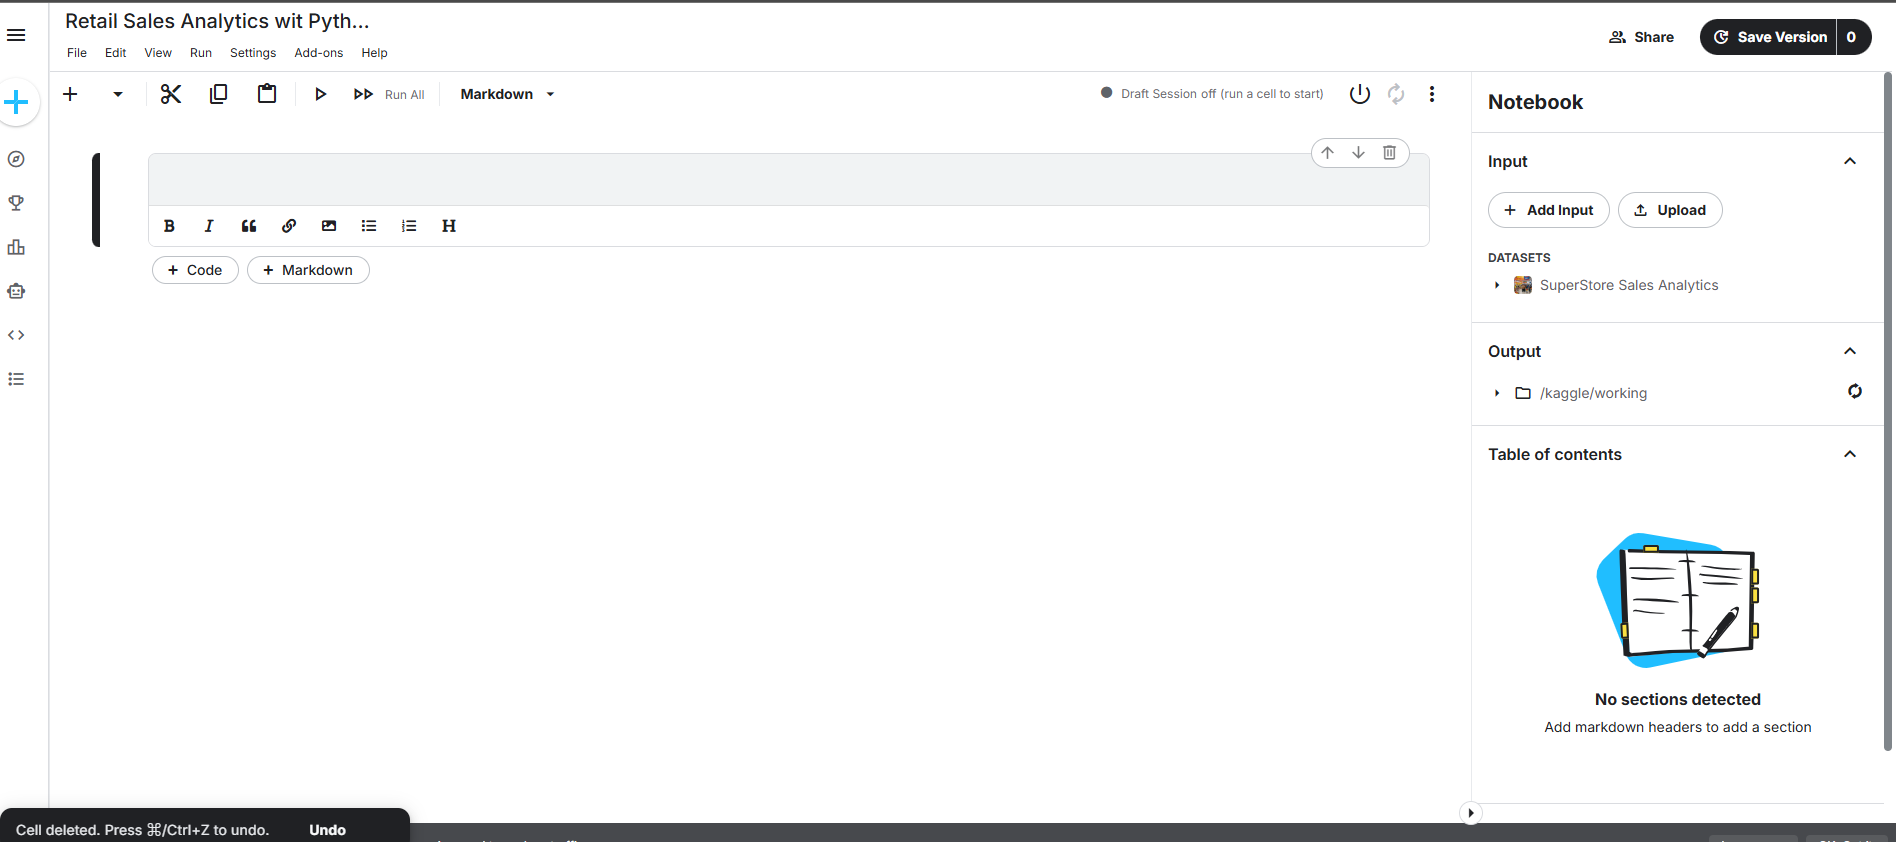

## Import Libraries

In [84]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import plotly.express as px

# Notebook configuration
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

In [85]:
# --------------------------------------------------
# Visualization Theme
# --------------------------------------------------

PRIMARY_COLOR = "#2563EB"

def apply_layout(fig):

    fig.update_layout(
        template="plotly_white",

        width=950,
        height=550,

        font=dict(
            family="Arial",
            size=14,
            color="#2E2E2E"
        ),

        title=dict(
            x=0.5,
            xanchor="center",
            font=dict(
                size=22,
                family="Arial",
                color="#1F2937"
            )
        ),

        margin=dict(
            l=40,
            r=40,
            t=80,
            b=40
        ),

        hoverlabel=dict(
            bgcolor="white",
            font_size=13,
            font_family="Arial"
        ),

        plot_bgcolor="white",
        paper_bgcolor="white",

        showlegend=False
    )

    fig.update_xaxes(
        showline=False,
        showgrid=True,
        gridcolor="rgba(0,0,0,0.08)",
        zeroline=False
    )

    fig.update_yaxes(
        showline=False,
        showgrid=False,
        zeroline=False
    )

    return fig

## Load Dataset

In [86]:
file_path = "/kaggle/input/datasets/thuandao/superstore-sales-analytics/SuperStoreOrders - SuperStoreOrders.csv"

df = pd.read_csv(file_path, encoding="latin1")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


## Data Cleaning

Before performing any analysis, the dataset is inspected and cleaned to ensure consistency and accuracy.

The following preprocessing steps will be performed:

- Validate data types
- Convert date columns
- Convert numeric columns
- Check missing values
- Check duplicate records

In [87]:
df.dtypes

order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_name      object
segment            object
state              object
country            object
market             object
region             object
product_id         object
category           object
sub_category       object
product_name       object
sales              object
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority     object
year                int64
dtype: object

In [88]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    dayfirst=True
)

df["ship_date"] = pd.to_datetime(
    df["ship_date"],
    dayfirst=True
)

In [89]:
df["sales"] = (
    df["sales"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
)

In [90]:
df.isna().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [91]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [92]:
df = df.drop(columns="year")

### Data Cleaning Summary

The dataset was successfully prepared for analysis.

Key preprocessing steps included:

- Date columns were converted to datetime format.
- Sales values were converted from formatted strings to numeric values.
- No missing values were identified.
- No duplicate records were found.

The dataset is now ready for feature engineering and exploratory data analysis.

# Feature Engineering

Additional features are created to simplify time-based analyses and improve the readability of visualizations throughout the notebook.

In [93]:
# Create date features

df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month_name()
df["order_month_num"] = df["order_date"].dt.month
df["order_quarter"] = df["order_date"].dt.quarter

# Exploratory Data Analysis

The following analyses answer key business questions using visual exploration and business interpretation.

## Business Question 1

### How have sales evolved over time?

Understanding sales trends over time helps identify business growth patterns and provides a baseline for evaluating future performance.

In [94]:
sales_by_year = (
    df.groupby("order_year", as_index=False)["sales"]
      .sum()
)

sales_by_year

,order_year,sales
0,2011,2259511.0
1,2012,2677493.0
2,2013,3405860.0
3,2014,4300041.0


In [95]:
fig = px.line(
    sales_by_year,
    x="order_year",
    y="sales",
    markers=True,
    title="Annual Sales Trend"
)

fig.update_traces(line=dict(width=3))

fig.update_layout(
    template="plotly_white",
    xaxis_title="Year",
    yaxis_title="Sales (USD)",
    hovermode="x unified",
    yaxis_tickprefix="$",
    font=dict(size=14),
    xaxis=dict(
        tickmode="array",
        tickvals=sales_by_year["order_year"]
    )
)

fig.show()

### Interpretation

Annual sales increased steadily from 2011 to 2014, with the strongest growth observed between 2013 and 2014. This indicates sustained business expansion throughout the analyzed period.

### Business Insight

The consistent upward trend suggests that the company successfully increased its revenue year over year. Additional analyses are required to determine whether this growth was driven by specific markets, product categories, or customer segments.

## Business Question 2

### Which markets generate the highest sales?

Understanding which markets contribute the most revenue helps identify the company's strongest business areas and supports strategic decisions for future investments and expansion.

In [96]:
# Total sales by market

sales_by_market = (
    df.groupby("market", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=True)
)

sales_by_market

,market,sales
2,Canada,66932.0
1,Africa,783776.0
3,EMEA,806184.0
5,LATAM,2164687.0
6,US,2297354.0
4,EU,2938139.0
0,APAC,3585833.0


In [97]:
fig = px.bar(
    sales_by_market,
    x="sales",
    y="market",
    orientation="h",
    text="sales",
    title="Total Sales by Market"
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Sales (USD)",
    yaxis_title="Market",
    xaxis_tickprefix="$",
    font=dict(size=14)
)

fig.show()

### Interpretation

The distribution of sales across markets reveals significant differences in revenue generation. Some markets contribute substantially more to total sales, indicating stronger commercial performance and customer demand.

### Business Insight

High-performing markets should be prioritized for continued investment and customer retention strategies. Lower-performing markets may require further investigation to determine whether growth opportunities exist or if operational improvements are needed.

## Business Question 3

### Which regions generate the highest sales?

Analyzing sales performance by region helps identify geographic areas that contribute the most to overall revenue and highlights opportunities for regional growth.

In [98]:
# Total sales by region

sales_by_region = (
    df.groupby("region", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
)

sales_by_region.head(10)

,region,sales
3,Central,2822399.0
10,South,1600960.0
7,North,1248192.0
9,Oceania,1100207.0
11,Southeast Asia,884438.0
8,North Asia,848349.0
5,EMEA,806184.0
0,Africa,783776.0
4,Central Asia,752839.0
12,West,725514.0


In [99]:
# Top 10 regions by sales

top_regions = sales_by_region.head(10)

fig = px.bar(
    top_regions,
    x="sales",
    y="region",
    orientation="h",
    text="sales",
    title="Top 10 Regions by Sales"
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Sales (USD)",
    yaxis_title="Region",
    xaxis_tickprefix="$",
    font=dict(size=14)
)

fig.update_yaxes(categoryorder="total ascending")

fig.show()

### Interpretation

Sales are not evenly distributed across regions. A small number of regions account for a significant share of total revenue, indicating strong geographic concentration.

### Business Insight

Identifying the highest-performing regions enables the company to focus investments, strengthen customer relationships, and replicate successful strategies in similar markets. Lower-performing regions should be evaluated to identify potential barriers to growth.

## Business Question 4

### Which product categories contribute the most to total sales?

Understanding the contribution of each product category helps identify the company's primary revenue drivers and supports decisions regarding inventory management, marketing strategies, and resource allocation.

In [100]:
# Sales by Category
sales_by_category = (
    df.groupby("category")["sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

sales_by_category

,category,sales
0,Technology,4744691.0
1,Furniture,4110884.0
2,Office Supplies,3787330.0


In [101]:
import plotly.express as px

fig = px.pie(
    sales_by_category,
    names="category",
    values="sales",
    hole=0.55,
    title="Total Sales by Product Category"
)

apply_layout(fig)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

### Interpretation

Technology represents the largest share of total sales, making it the company's primary revenue-generating category. Office Supplies also contributes a significant portion of sales, while Furniture accounts for the smallest share among the three categories.

### Business Insight

The sales distribution indicates that Technology is the company's strongest product category and should remain a strategic focus for revenue growth. Although Furniture contributes less to total sales, additional analysis of profitability and discount levels may reveal opportunities to improve its overall business performance.

## Business Question 5

### Which product subcategories generate the highest sales?

Analyzing sales at the subcategory level provides a more detailed understanding of customer demand. This analysis helps identify top-performing products, prioritize inventory planning, and uncover opportunities to optimize the product portfolio.

In [102]:
# Sales by Subcategory
sales_by_subcategory = (
    df.groupby("sub_category")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

sales_by_subcategory

,sub_category,sales
0,Phones,1706874.0
1,Copiers,1509439.0
2,Chairs,1501682.0
3,Bookcases,1466559.0
4,Storage,1127124.0
5,Appliances,1011081.0
6,Machines,779071.0
7,Tables,757034.0
8,Accessories,749307.0
9,Binders,461952.0


In [103]:
fig = px.bar(
    sales_by_subcategory,
    x="sales",
    y="sub_category",
    orientation="h",
    title="Top 10 Product Subcategories by Sales",
    text_auto=".2s"
)

apply_layout(fig)

fig.update_layout(
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

## Business Question 6

### Which product categories generate the highest profit?

While sales indicate revenue generation, profit reveals the actual financial contribution of each product category. Analyzing profitability helps identify the categories that create the greatest business value and supports strategic decisions regarding pricing, product mix, and investment.

In [104]:
# Profit by Category
profit_by_category = (
    df.groupby("category")["profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

profit_by_category

,category,profit
0,Technology,663778.73318
1,Office Supplies,518473.83430
2,Furniture,286782.25380


In [105]:
fig = px.pie(
    profit_by_category,
    names="category",
    values="profit",
    hole=0.55,
    title="Profit by Product Category"
)

apply_layout(fig)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

### Interpretation

Profitability is not distributed equally across product categories. While some categories contribute significantly to overall profit, others generate a smaller share despite their sales performance, highlighting differences in profit margins.

### Interpretation

Profitability is not distributed equally across product categories. While some categories contribute significantly to overall profit, others generate a smaller share despite their sales performance, highlighting differences in profit margins.

## Business Question 7

### How do discounts affect profitability?

Discounts can help increase sales, but excessive discounts may reduce profit margins. Analyzing the relationship between discounts and profit helps identify pricing strategies that maximize profitability while maintaining competitive sales performance.

In [106]:
# Discount vs Profit
discount_profit = df[["discount", "profit"]]

discount_profit.head()

,discount,profit
0,0.0,106.140
1,0.1,36.036
2,0.0,29.640
3,0.5,-26.055
4,0.1,37.770


In [107]:
# Create a copy with only the required columns
discount_profit = df[["discount", "profit"]].copy()


# Classify each transaction by profit level
def profit_level(profit):
    if profit < 0:
        return "Loss"
    elif profit < 100:
        return "Low Profit"
    else:
        return "High Profit"


discount_profit["profit_level"] = discount_profit["profit"].apply(profit_level)

discount_profit.head()

,discount,profit,profit_level
0,0.0,106.140,High Profit
1,0.1,36.036,Low Profit
2,0.0,29.640,Low Profit
3,0.5,-26.055,Loss
4,0.1,37.770,Low Profit


In [108]:
fig = px.scatter(
    discount_profit,
    x="discount",
    y="profit",
    color="profit_level",
    opacity=0.60,
    title="Discount vs Profit",
    trendline="ols",
    color_discrete_map={
        "Loss": "#DC2626",
        "Low Profit": "#FACC15",
        "High Profit": "#16A34A"
    }
)

apply_layout(fig)

fig.show()

### Interpretation

The scatter plot suggests a negative relationship between discounts and profit. As discount levels increase, profits tend to decrease, although some transactions remain profitable even with moderate discounts. The wide dispersion indicates that additional factors also influence profitability.

### Business Insight

High discounts should be carefully monitored, as they may reduce overall profitability. Establishing discount guidelines based on product performance and customer segments can help maximize profit while maintaining competitive pricing.

## Business Question 8

### Which customer segments contribute the most to sales and profit?

Understanding customer segment performance helps identify the most valuable customer groups. Comparing both sales and profit provides insights into which segments generate the highest revenue while maintaining strong profitability.

In [109]:
# Sales and Profit by Customer Segment
segment_performance = (
    df.groupby("segment")[["sales", "profit"]]
      .sum()
      .reset_index()
)

segment_performance

,segment,sales,profit
0,Consumer,6508141.0,749239.78206
1,Corporate,3824808.0,442785.85866
2,Home Office,2309956.0,277009.18056


In [110]:
fig = px.bar(
    segment_performance,
    x="segment",
    y=["sales", "profit"],
    barmode="group",
    title="Sales and Profit by Customer Segment",
    text_auto=".2s"
)

apply_layout(fig)

fig.show()

### Interpretation

Customer segments contribute differently to revenue and profitability. While some segments generate the highest sales, their profit contribution may not increase at the same rate, highlighting differences in customer value and purchasing behavior.

### Interpretation

Customer segments contribute differently to revenue and profitability. While some segments generate the highest sales, their profit contribution may not increase at the same rate, highlighting differences in customer value and purchasing behavior.

## Business Question 9

### Which shipping modes are used most frequently?

Shipping mode analysis helps identify customer delivery preferences and supports logistics planning. Understanding the distribution of shipping methods can help optimize operational costs while maintaining customer satisfaction.

In [111]:
# Orders by Shipping Mode
shipping_mode = (
    df.groupby("ship_mode")
      .size()
      .reset_index(name="orders")
      .sort_values("orders", ascending=False)
)

shipping_mode

,ship_mode,orders
3,Standard Class,30775
2,Second Class,10309
0,First Class,7505
1,Same Day,2701


In [112]:
fig = px.bar(
    shipping_mode,
    x="orders",
    y="ship_mode",
    orientation="h",
    title="Orders by Shipping Mode",
    text_auto=True
)

apply_layout(fig)

fig.update_layout(
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

### Interpretation

Standard shipping is the most frequently used delivery method, while expedited shipping options account for a smaller share of total orders. This indicates that most customers prioritize standard delivery over faster shipping alternatives.

### Business Insight

Understanding shipping preferences helps businesses optimize logistics operations and transportation costs. Since standard shipping dominates order volume, improving its efficiency can have the greatest impact on customer satisfaction and operational performance.

## Business Question 10

### How long does it take to deliver an order?

Delivery time is a key operational metric that directly impacts customer satisfaction. Analyzing shipping performance helps identify delivery efficiency and evaluate whether different shipping modes meet expected service levels.

In [113]:
# Calculate delivery time in days
df["delivery_days"] = (df["ship_date"] - df["order_date"]).dt.days

df[["order_date", "ship_date", "delivery_days"]].head()

,order_date,ship_date,delivery_days
0,2011-01-01,2011-01-06,5
1,2011-01-01,2011-01-08,7
2,2011-01-01,2011-01-05,4
3,2011-01-01,2011-01-05,4
4,2011-01-01,2011-01-08,7


In [114]:
# Average delivery time by shipping mode
delivery_time = (
    df.groupby("ship_mode")["delivery_days"]
      .mean()
      .sort_values()
      .reset_index()
)

delivery_time

,ship_mode,delivery_days
0,Same Day,0.037394
1,First Class,2.181746
2,Second Class,3.230187
3,Standard Class,4.998018


In [115]:
fig = px.bar(
    delivery_time,
    x="ship_mode",
    y="delivery_days",
    title="Average Delivery Time by Shipping Mode",
    text_auto=".1f"
)

apply_layout(fig)

fig.show()

### Interpretation

Shipping modes show clear differences in average delivery time. Premium shipping options consistently deliver orders faster, while standard shipping requires more time to complete deliveries.

### Business Insight

Delivery performance is a critical factor in customer satisfaction. Monitoring average delivery times helps evaluate logistics efficiency and ensures that premium shipping services provide the expected value compared to standard delivery options.

# Executive Summary

This analysis explored sales performance, profitability, customer behavior, and shipping efficiency using the Global Superstore dataset. The findings highlight the company's strongest revenue drivers, the impact of discount strategies, customer segment performance, and logistics trends.

Overall, the analysis provides actionable insights that can support better decision-making across sales, marketing, pricing, inventory management, and supply chain operations.

## Key Findings

- Technology is the highest-performing product category in terms of sales and profitability.
- Sales are concentrated within a limited number of product subcategories, indicating clear revenue drivers.
- Higher discount levels are generally associated with lower profitability and an increased number of loss-making transactions.
- Customer segments contribute differently to both sales and profit, emphasizing the importance of targeted marketing strategies.
- Standard Shipping is the most frequently used delivery method, while premium shipping options provide faster delivery times.

## Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Prioritize investment in high-performing product categories and subcategories.
2. Review discount policies to reduce unnecessary profit erosion.
3. Focus marketing efforts on customer segments with the highest profitability.
4. Monitor product categories with strong sales but lower profit margins.
5. Continue optimizing Standard Shipping due to its high order volume.
6. Evaluate premium shipping services to ensure they provide sufficient customer value.
7. Use data-driven pricing strategies to balance revenue growth and profitability.

## Final Conclusion

This project demonstrates how exploratory data analysis can transform raw transactional data into meaningful business insights. By combining data cleaning, feature engineering, visualization, and business interpretation, the analysis identifies opportunities to improve sales performance, profitability, and operational efficiency.

The findings can support strategic decision-making while illustrating practical applications of Python, Pandas, and Plotly for business analytics.